# Intro to EDA


Exploratory data analysis, or EDA, is a standard practice prior to any data manipulation and analysis.

Recall that data engineering is primarily about data preparation to *serve* smooth and effective data analysis.  Exploratory data analysis generally refers to the step of understanding the data:  

- **summarizing characteristics of raw data**
- **visualizing data (single and multiple variables)**
- identifying missing data
- identifying outliers

This document primarily deals with the first two items.  

## Goals
In the **exploratory** phase, these are for people behind the scenes to see.  

The main goals here are:

- capture main message
- (relatively) quick exploration across many summaries (including plots)
- *not* intended for a client or presentation

What does this translate to, technically?

- each summary should have meaningful information
- **label** your plots

## Data summary
As a starting point, simply looking at the data is worth the while.  Some common questions to consider are the following:  


1. General dataset info: size, dtypes  
2. Missing values?  
3. Duplicate data?  
4. Continuous variables  
5. Categorical variables  
6. Bivariate relationships  
7. Potential data quality issues, e.g., inconsistency, special NA characters

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Earthquake dataset

[Source Link](https://open.canada.ca/data/en/dataset/2c3672b6-4c17-4ff5-9861-29e2dd6d03b3/resource/9cfea46f-561a-440f-9d17-fed3557fc7b5)

In [62]:
# load and save a copy of the earthquake dataset
earthquake = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/Canadian-Earthquakes-2010-2019.csv')

In [63]:
# take a glimpse of the data
earthquake.head()
earthquake.tail()

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
44556,<2,1.8,ML,2019-12-31T18:37:24+0000,"31 km SE of Ashcroft, BC",14.0,50.487999,-121.035004,44557,-121.035415,50.487806
44557,2,2.4,MN,2019-12-31T22:18:53+0000,"Blast, Laronde Mine, QC",0.0,48.250000,-78.448997,44558,-78.449004,48.250409
44558,2,2.0,ML,2019-12-31T23:11:07+0000,"29 km SE of Ashcroft, BC",10.5,50.526001,-121.005997,44559,-121.006115,50.526206
44559,<2,1.9,MN,2019-12-31T23:53:23+0000,"6 km N from Cornwall, ON",18.0,45.083000,-74.718002,44560,-74.718302,45.083409
44560,<2,1.3,MN,2019-12-31T23:54:02+0000,"CHARLEVOIX SEISMIC ZONE, QC.",3.8,47.492001,-70.412003,44561,-70.412401,47.491910


In [64]:
# view a summary of the full data
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


In [65]:
# checks for duplicates (also ask if duplicates make sense)
earthquake.duplicated().any()

np.False_

In [66]:
# duplicates
earthquake[earthquake.duplicated()] # empty dataframe, no duplicates

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom


In [67]:
# a quick numerical summary 
earthquake.describe()

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
count,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000
mean,2.134070,12.852194,53.351863,-118.953322,22281.000000,-118.953299,53.351830
std,0.828096,9.963145,6.214464,23.696484,12863.797009,23.696493,6.214465
min,-1.400000,-0.500000,40.808998,-148.811005,1.000000,-148.810526,40.808509
25%,1.600000,5.000000,49.169998,-132.427994,11141.000000,-132.427618,49.170009
50%,2.100000,10.000000,52.137001,-129.671997,22281.000000,-129.672016,52.136507
75%,2.700000,18.000000,56.514999,-121.947998,33421.000000,-121.948318,56.515206
max,7.700000,214.000000,82.608002,-39.320000,44561.000000,-39.319968,82.607812


In [68]:
# checks for possible statistical assumption(s)
import scipy.stats as sps

In [69]:
# extract only numeric variables
earthquake_num = earthquake.select_dtypes('number')

In [70]:
earthquake_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   magnitude       44561 non-null  float64
 1   depth           44561 non-null  float64
 2   latitude        44561 non-null  float64
 3   longitude       44561 non-null  float64
 4   OBJECTID        44561 non-null  int64  
 5   longitude_geom  44561 non-null  float64
 6   latitude_geom   44561 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.4 MB


In [71]:
# for example, normality test
sps.normaltest(earthquake_num)

NormaltestResult(statistic=array([ 1597.66581247, 15302.56967363,  9387.86913782,  8551.48250207,
       39401.07756051,  8551.48413702,  9387.85609679]), pvalue=array([0., 0., 0., 0., 0., 0., 0.]))

In [72]:
# for example, another normality test
sps.shapiro(earthquake_num.iloc[:, 1])

c:\Users\flowe\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44561.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9052753775261462), pvalue=np.float64(4.796965355545974e-93))

In [73]:
# pairwise correlation
earthquake_num.corr()

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
magnitude,1.000000,-0.127958,0.196699,-0.110731,-0.006523,-0.110731,0.196699
depth,-0.127958,1.000000,-0.107744,-0.005796,-0.103983,-0.005796,-0.107744
latitude,0.196699,-0.107744,1.000000,-0.266265,-0.000391,-0.266265,1.000000
longitude,-0.110731,-0.005796,-0.266265,1.000000,0.049094,1.000000,-0.266265
OBJECTID,-0.006523,-0.103983,-0.000391,0.049094,1.000000,0.049093,-0.000390
longitude_geom,-0.110731,-0.005796,-0.266265,1.000000,0.049093,1.000000,-0.266265
latitude_geom,0.196699,-0.107744,1.000000,-0.266265,-0.000390,-0.266265,1.000000


## Data visualization

In [74]:
sns.set(context='talk', style='ticks')  # simply for aesthetics
sns.set_palette('magma')
%matplotlib inline 

earthquake_sample = earthquake.sample(n=500)  # (if too slow) for illustration purposes

<Axes: ylabel='Frequency'>

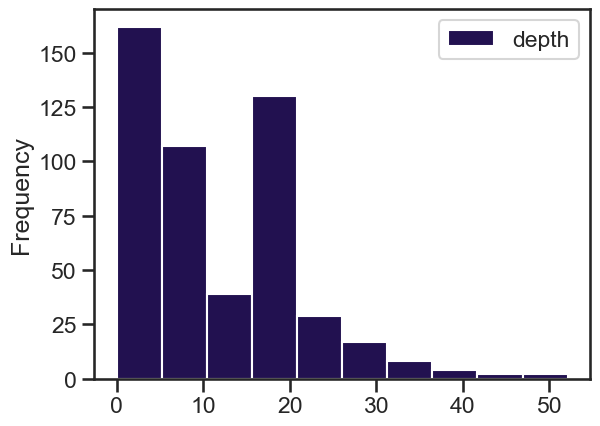

In [75]:
# histogram for continuous variables using pandas built-in plots 
earthquake_sample.plot.hist(column='depth')

<Axes: xlabel='depth', ylabel='Probability'>

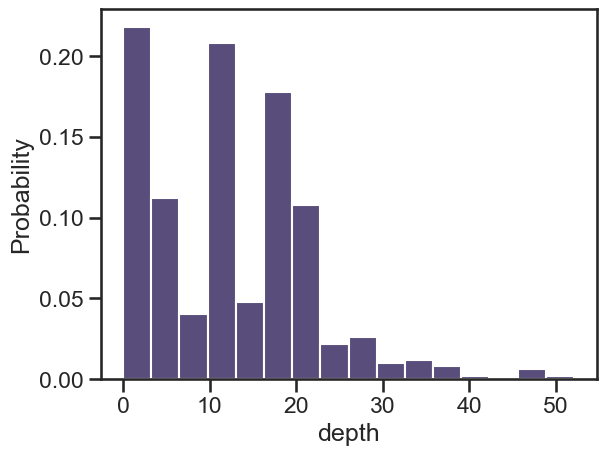

In [76]:
# relative frequency? ...
sns.histplot(x='depth', data=earthquake_sample, stat='probability')

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 10037 to 17905
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  500 non-null    object 
 1   magnitude           500 non-null    float64
 2   magnitude_type      498 non-null    object 
 3   date                500 non-null    object 
 4   place               500 non-null    object 
 5   depth               500 non-null    float64
 6   latitude            500 non-null    float64
 7   longitude           500 non-null    float64
 8   OBJECTID            500 non-null    int64  
 9   longitude_geom      500 non-null    float64
 10  latitude_geom       500 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 46.9+ KB


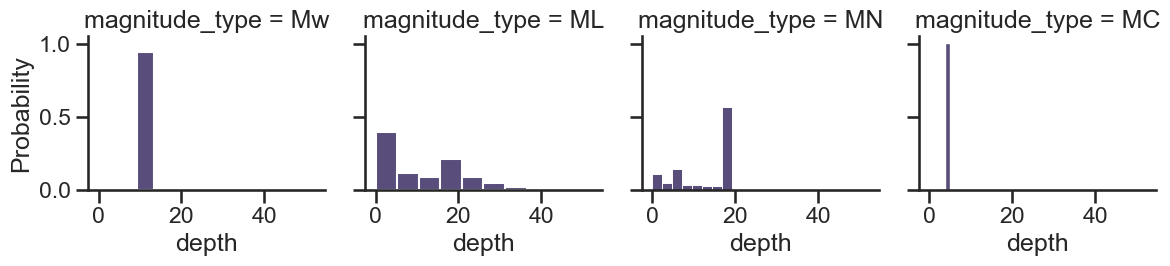

In [77]:
# histogram of masses by group
earthquake_sample.info()
g = sns.FacetGrid(earthquake_sample, col='magnitude_type')
g.map(sns.histplot, 'depth', stat='probability')

c:\Users\flowe\miniconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


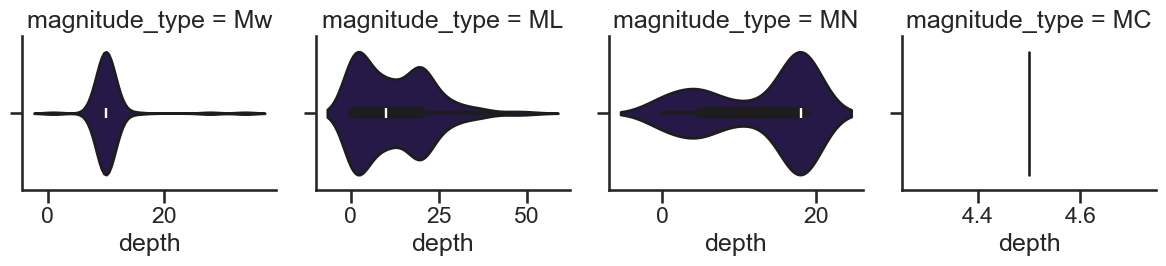

In [78]:
# other types of plots
g = sns.FacetGrid(earthquake_sample, col='magnitude_type', sharex=False)
g.map(sns.violinplot, 'depth')

<Axes: xlabel='magnitude_type', ylabel='count'>

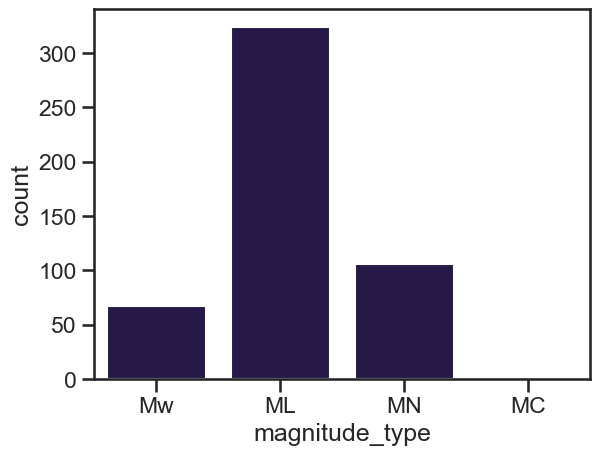

In [79]:
# counts for categorical variables
sns.countplot(x='magnitude_type', data=earthquake_sample)

<Axes: xlabel='magnitude_type', ylabel='depth'>

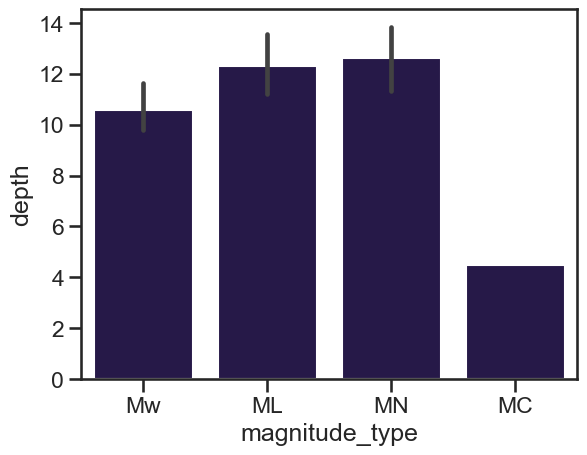

In [80]:
# barplots by group
sns.barplot(x='magnitude_type', y='depth', data=earthquake_sample)

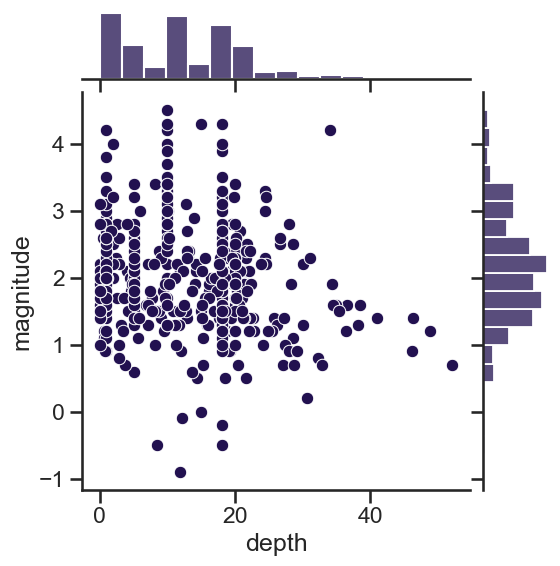

In [81]:
# bivariate plots
sns.jointplot(x='depth', y='magnitude', data=earthquake_sample)

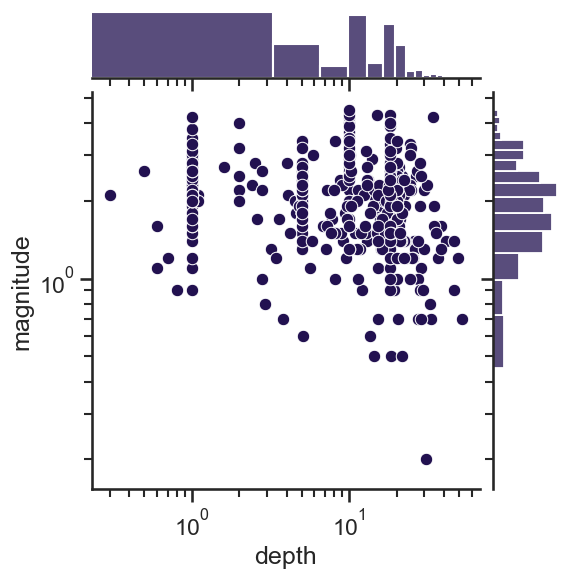

In [82]:
# bivariate plots (log-log)
sns.jointplot(x='depth', y='magnitude', data=earthquake_sample)
plt.xscale('log')
plt.yscale('log')

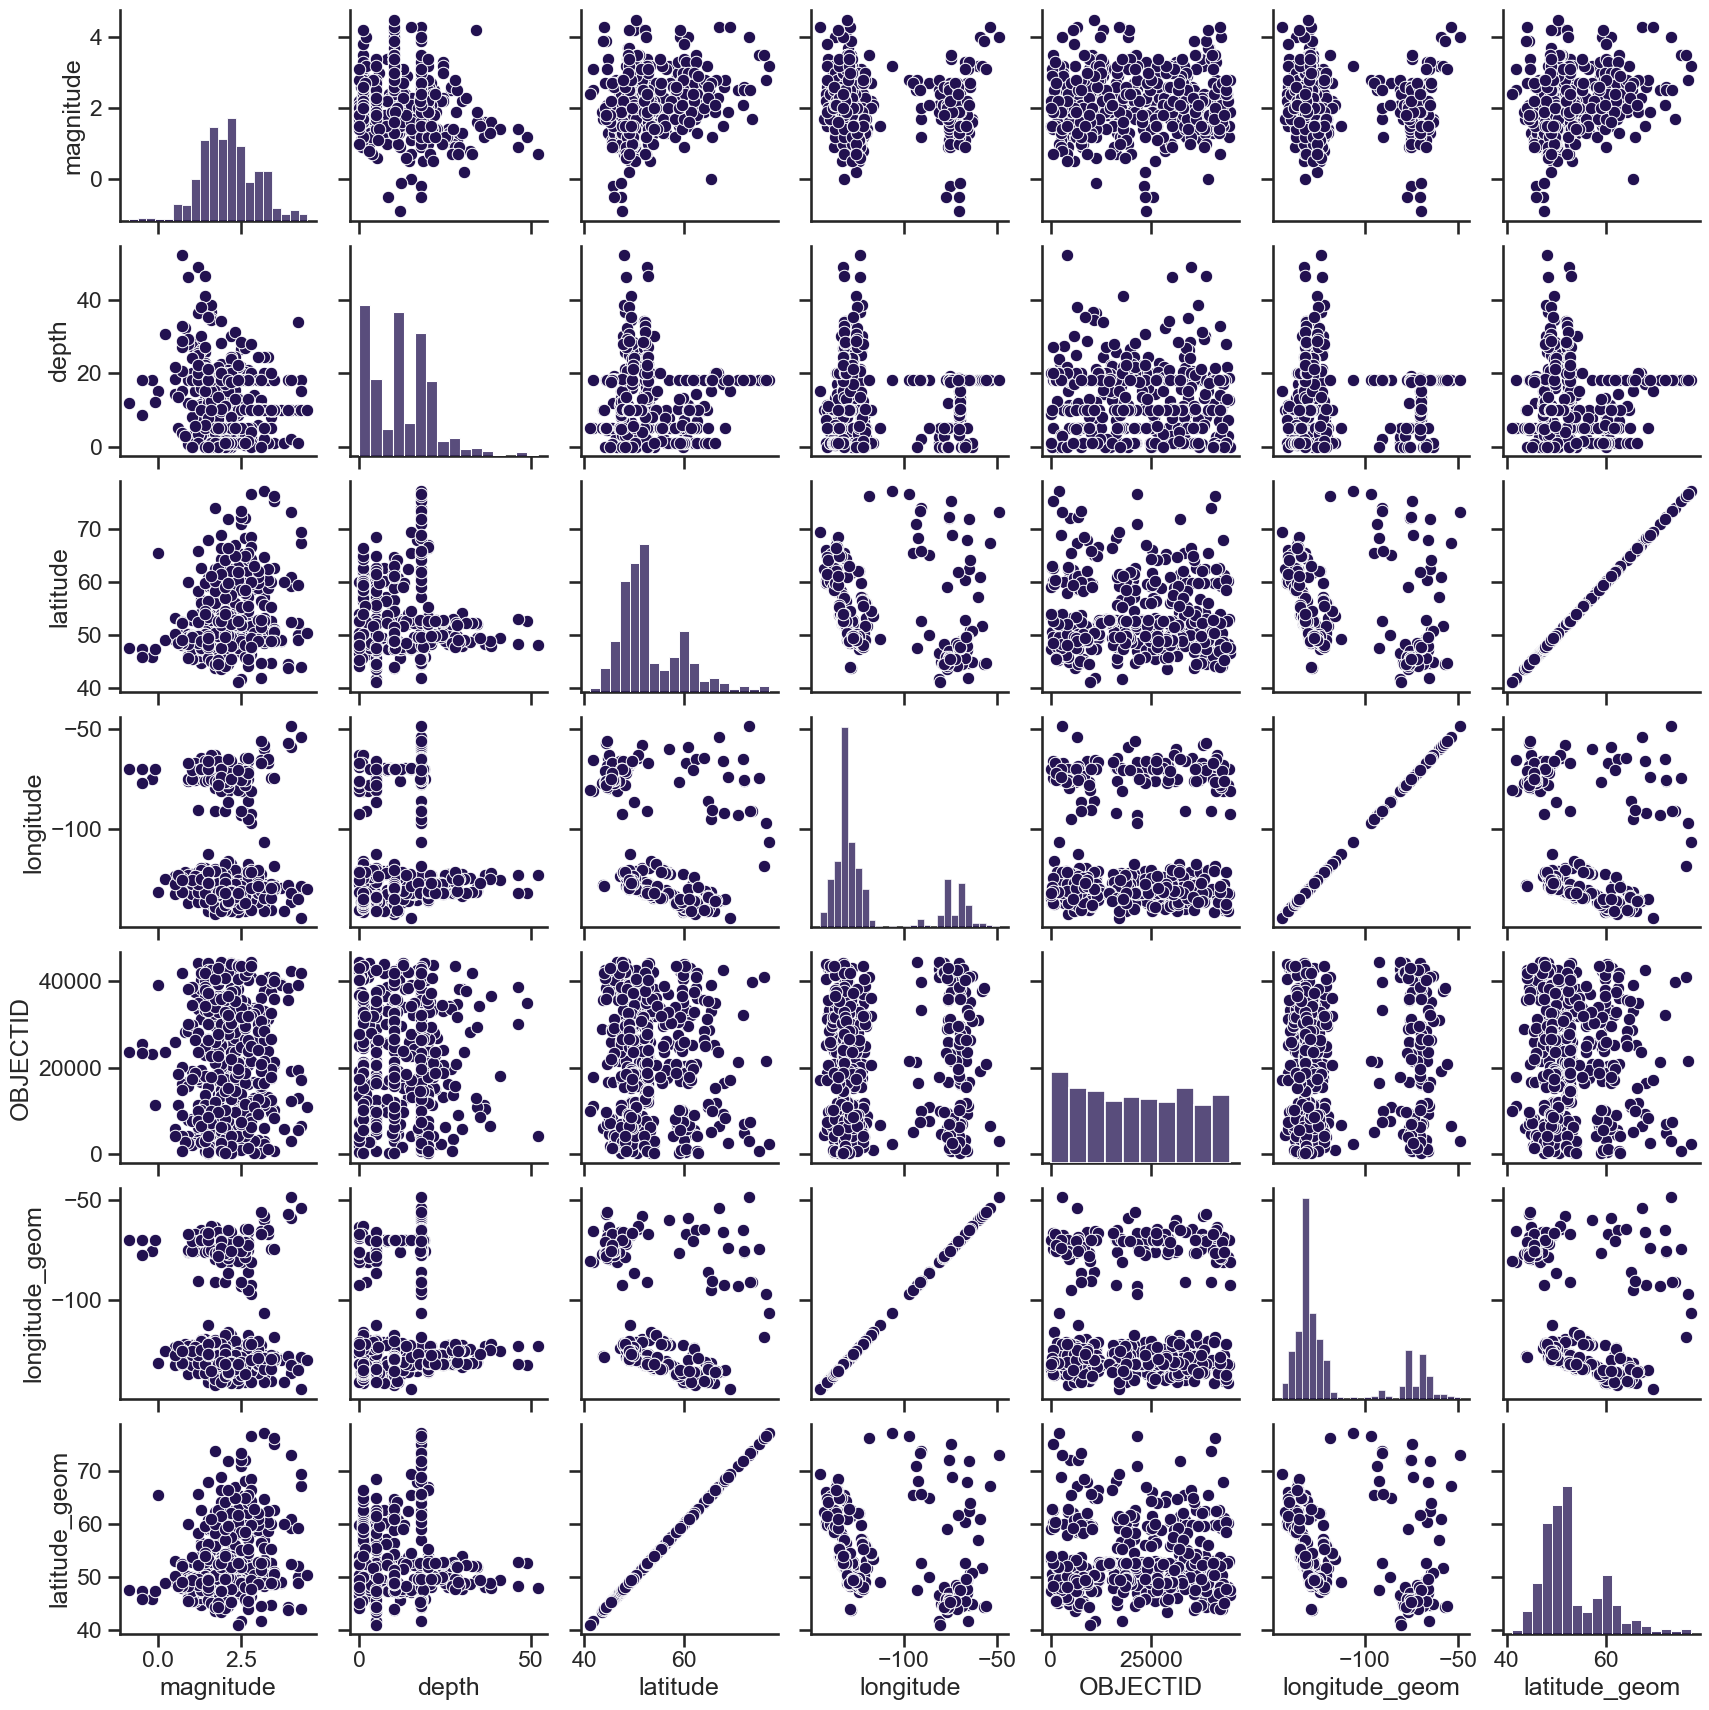

In [83]:
# pairwise plots  (time-consuming)
g = sns.pairplot(earthquake_sample)

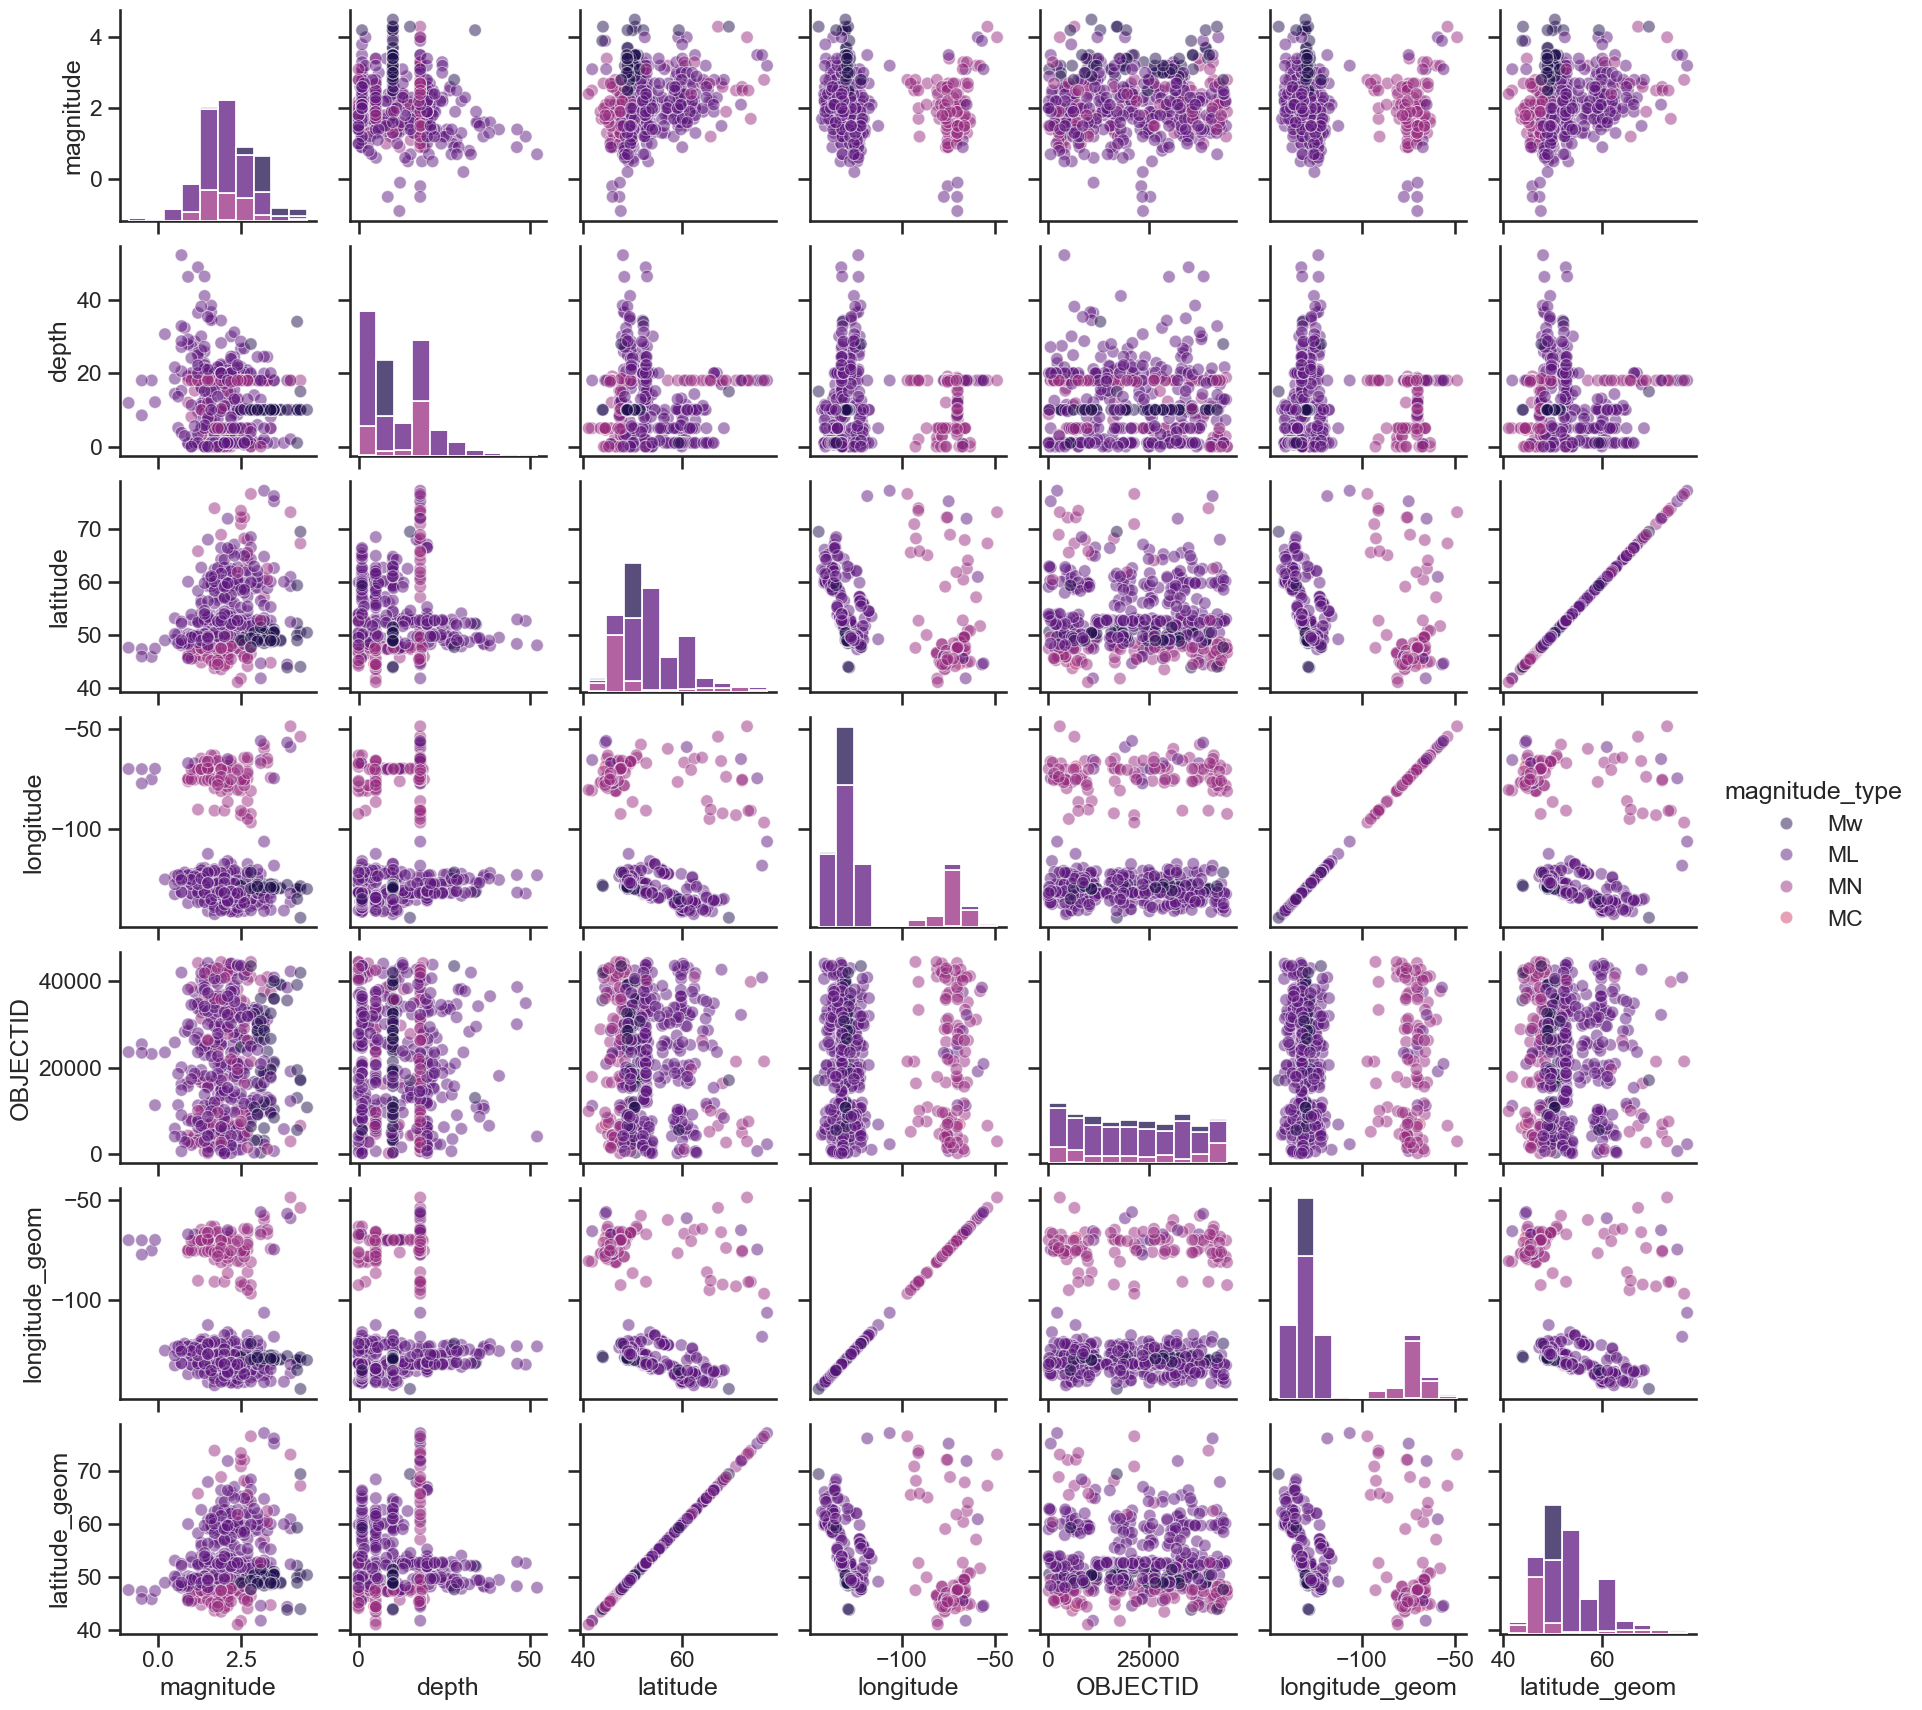

In [84]:
# another pairwise plot by group
g = sns.pairplot(earthquake_sample, hue='magnitude_type',
                 diag_kind='hist', diag_kws={'multiple': 'stack', 'bins': 10},
                 plot_kws={'alpha': 0.5})

## In-class activity
Refer to the following figure, choose two subfigures to reproduce with the earthquake dataset.

![](../datasets/earthquake_analysis-2010-2019.png)

Text(0, 0.5, 'Count')

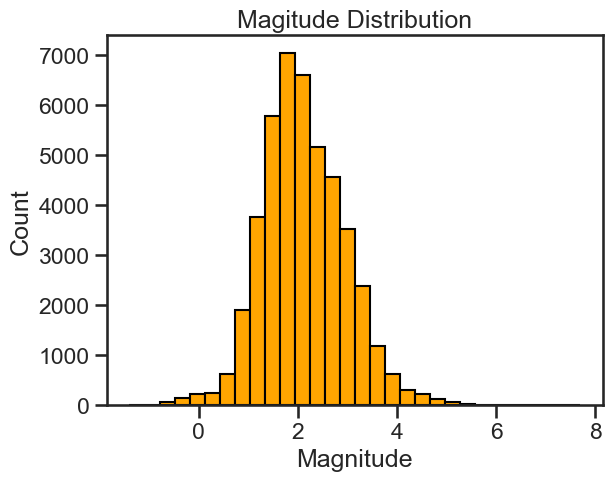

In [85]:
# Magnitude distribution graph
g1 = earthquake.plot.hist(column='magnitude', bins=30, color='orange', edgecolor='black')
g1.legend().remove()
g1.set_title('Magitude Distribution')
g1.set_xlabel('Magnitude')
g1.set_ylabel('Count')

Text(0, 0.5, 'Latitude')

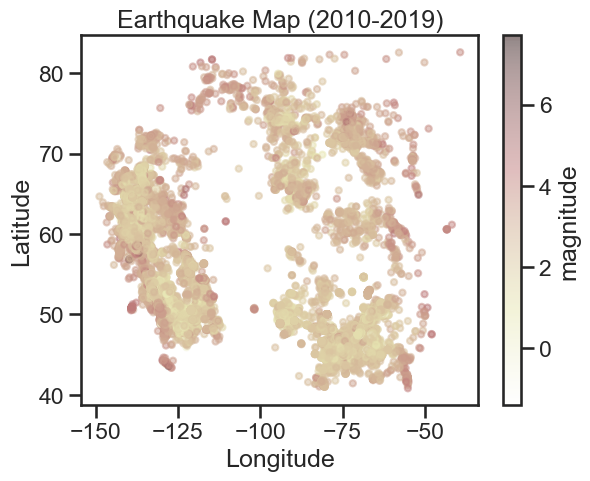

In [86]:
# Earthquake map (2010-2019) graph
g2 = earthquake.plot.scatter(x='longitude', y='latitude', alpha=0.5, c='magnitude', cmap='pink_r')
g2.set_title('Earthquake Map (2010-2019)')
g2.set_xlabel('Longitude')
g2.set_ylabel('Latitude')


Text(0, 0.5, 'Count')

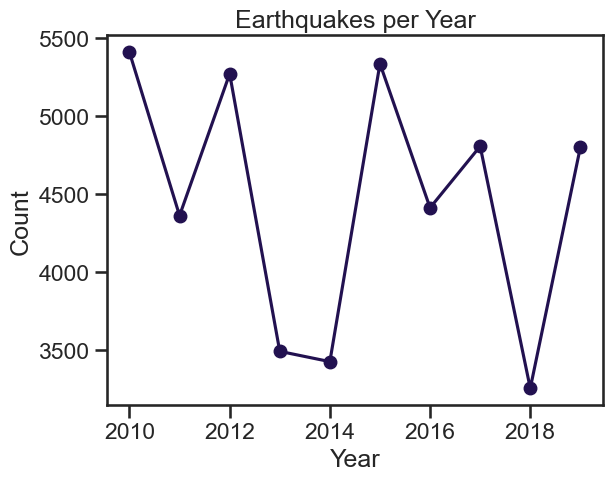

In [87]:
# Earthquakes per year graph
earthquake_timeseries = earthquake.copy()
earthquake_timeseries['year'] = pd.to_datetime(earthquake_timeseries['date']).dt.year # extract year from date

df_timeseries = earthquake_timeseries.groupby('year').size() # group by year and count the number of earthquakes per year
g3 = df_timeseries.plot.line(marker='o')
g3.set_title('Earthquakes per Year')
g3.set_xlabel('Year')
g3.set_ylabel('Count')

Text(0, 0.5, 'Depth')

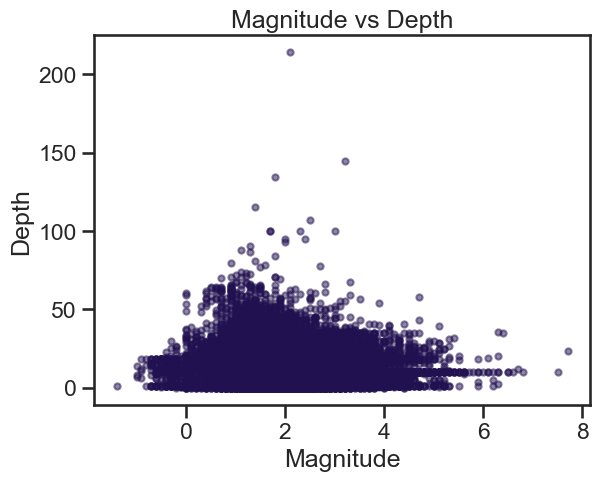

In [88]:
# Magnitude vs Depth graph
g4 = earthquake.plot.scatter(x='magnitude', y='depth', alpha=0.5)
g4.set_title('Magnitude vs Depth')
g4.set_xlabel('Magnitude')
g4.set_ylabel('Depth')

Text(0, 0.5, 'Count')

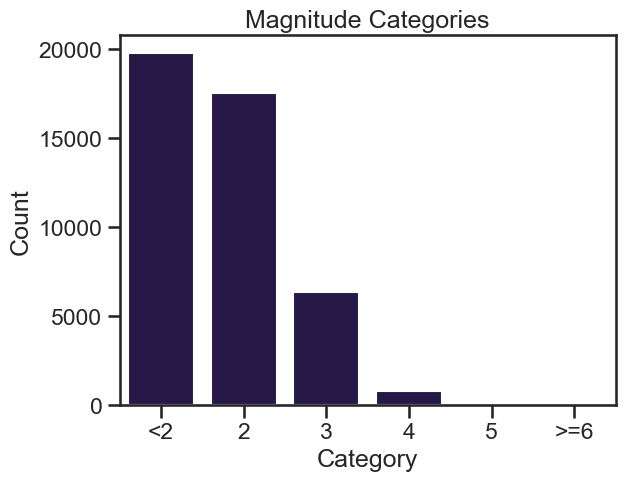

In [89]:
# Magnitude categories graph
g5 = sns.countplot(x='magnitude_codelist', data=earthquake)
g5.set_title('Magnitude Categories')
g5.set_xlabel('Category')
g5.set_ylabel('Count')

Text(0.5, 1.0, 'Earthquakes by Year')

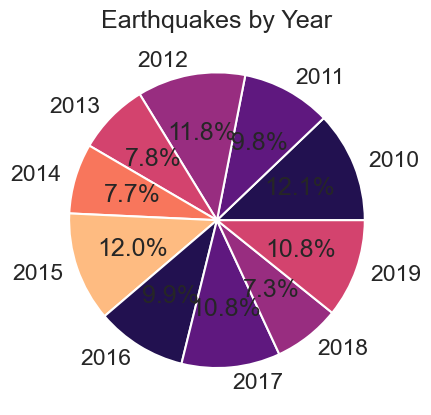

In [90]:
# Pie chart
# Variable chosen is 'year'
g6 = df_timeseries.plot.pie(autopct='%1.1f%%')
g6.set_title('Earthquakes by Year')



---

*Note:* These notes are adapted from a blog post on [Tom's Blog](https://tomaugspurger.net/posts/modern-6-visualization/).
